In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Charan\Desktop\JavaScript\Internship\TAKEITSMART\exams.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [3]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000
std,15.402871,14.737272,15.600985
min,13.000000,27.000000,23.000000
25%,56.000000,60.000000,58.000000
50%,66.500000,70.000000,68.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


In [4]:
df.shape

(1000, 8)

In [5]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
df.duplicated().sum()

1

In [9]:
df['reading score'].duplicated().sum()
df['writing score'].duplicated().sum()
df['gender'].duplicated().sum()

998

In [10]:
for col in df.columns:
    print(col, df[col].duplicated().sum())

gender 998
race/ethnicity 995
parental level of education 994
lunch 998
test preparation course 998
math score 923
reading score 927
writing score 924


In [11]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     77
reading score                  73
writing score                  76
dtype: int64

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000
std,15.402871,14.737272,15.600985
min,13.000000,27.000000,23.000000
25%,56.000000,60.000000,58.000000
50%,66.500000,70.000000,68.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


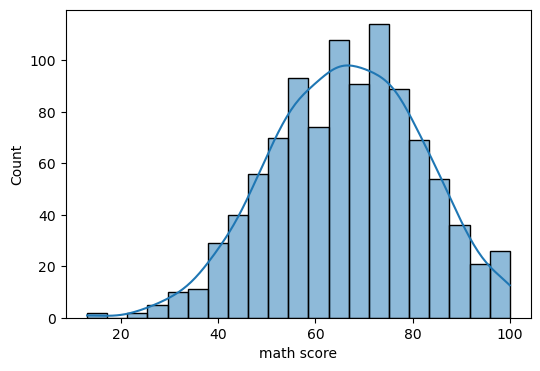

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['math score'], kde=True)
plt.show()

<AxesSubplot:xlabel='reading score', ylabel='Count'>

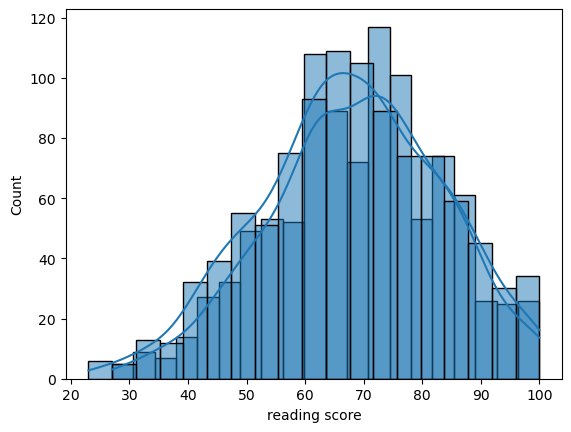

In [14]:
sns.histplot(df['reading score'], kde=True)
sns.histplot(df['writing score'], kde=True)

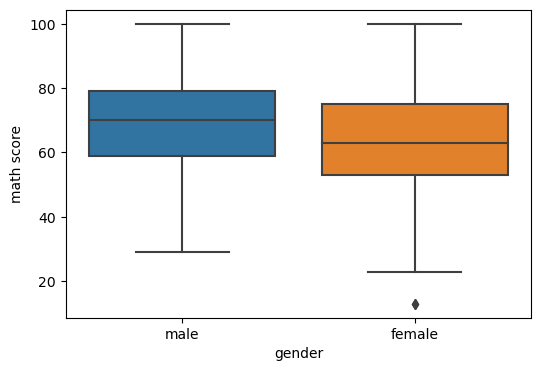

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='math score', data=df)
plt.show()

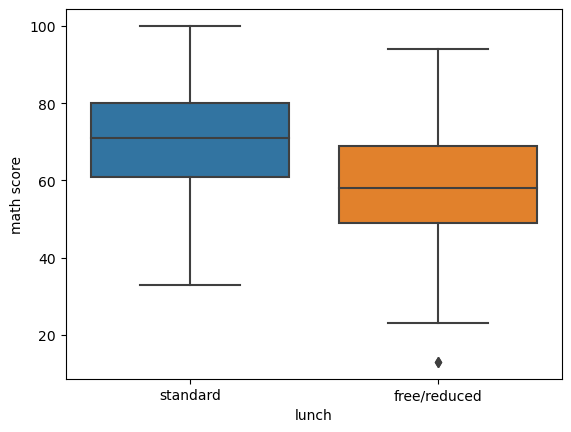

In [16]:
sns.boxplot(x='lunch', y='math score', data=df)
plt.show()

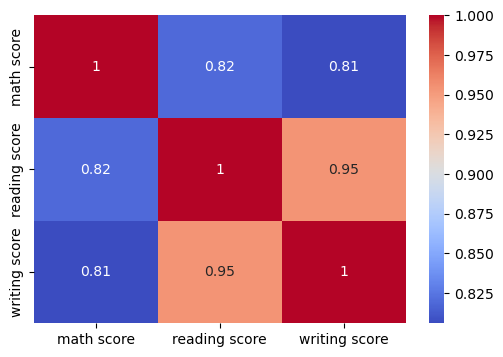

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score','reading score','writing score']].corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

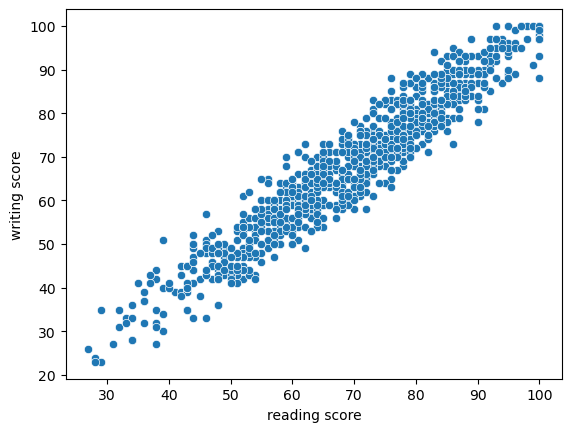

In [18]:
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.show()

In [19]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

In [20]:
def performance(x):
    if x < 50:
        return "Low"
    elif x < 75:
        return "Medium"
    else:
        return "High"

df['performance'] = df['average_score'].apply(performance)

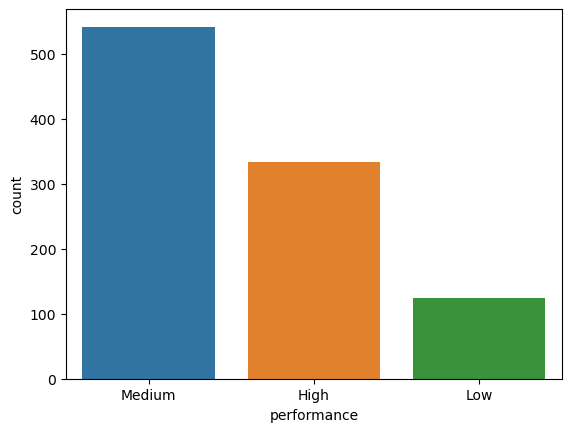

In [21]:
sns.countplot(x='performance', data=df)
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
le = LabelEncoder()

In [23]:
df['gender'] = le.fit_transform(df['gender'])
df['race/ethnicity'] = le.fit_transform(df['race/ethnicity'])
df['parental level of education'] = le.fit_transform(df['parental level of education'])
df['lunch'] = le.fit_transform(df['lunch'])
df['test preparation course'] = le.fit_transform(df['test preparation course'])
df['performance'] = le.fit_transform(df['performance'])

In [24]:
X = df.drop(['performance','average_score'], axis=1)
y = df['performance']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial',max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, multi_class='multinomial')

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.99
[[73  0  0]
 [ 0 29  0]
 [ 1  1 96]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        73
           1       0.97      1.00      0.98        29
           2       1.00      0.98      0.99        98

    accuracy                           0.99       200
   macro avg       0.98      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

